# Objective: 

<pre>
Consider the points in the file - 

Implement a clustering algorithm to consistently group together the points, justifying your choices. 

How do you manage the further requirement that points having negative first coordinate should not be in the same clusters as those having positive first coordinate? 

For each solution, please provide the commented code, and  
</pre>

- Illustrate solutions;  
- Graphically represent the results 
-  Justify your choices. 

# Necessary libraries

In [1]:
import os
import sys

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Utilities

In [3]:
uti_path = r'C:\Users\s3tpqt\OneDrive - Swiss Reinsurance Company Ltd\Documents\projects & tasks\utility_scripts'
sys.path.append(uti_path)

In [4]:
import utility

# Exploration

In [5]:
pts = pd.read_excel('pts.xlsx', header=None)
pts.columns = ['x', 'y']
pts.sample(5)

,x,y
129,-0.073135,-0.834962
159,-0.178975,-1.364888
286,1.295077,0.501395
107,0.114922,-0.888196
274,-0.610581,-1.802595


In [6]:
utility.get_df_info(pts)

,column,column_type,null_count,null_percent,unique_count,unique_percent,min_value,max_value,unique_values
0,x,<class 'float'>,0,0.0,295,100.0,-1.330306,1.341061,"[0.075219688, -0.010374014, 0.09022497, 0.1174..."
1,y,<class 'float'>,0,0.0,295,100.0,-1.927601,2.040625,"[-0.134484277, -0.195678509, 0.141263106, 0.08..."


## Inspecting the scatter plot bw 'x' and 'y'

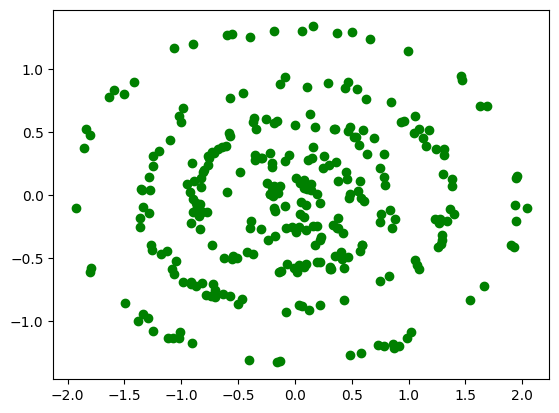

In [7]:
fig, ax = plt.subplots()
ax.scatter(pts['y'], pts['x'], color='g')

In [8]:
fig.savefig('x.png')

## Inspecting % of positive and negative values in the columns

In [9]:
sign_info = utility.get_sign_info_as_percent(pts, 'x', 'y', print_signed_pcts_col=True)

-1.0    52.2
 1.0    47.8
Name: x_sign_%, dtype: float64

 1.0    50.5
-1.0    49.5
Name: y_sign_%, dtype: float64



# Clustering experiments

- Centroid based can create problems becuase all clusters have the same centroid

In [10]:
X = pts.values
seed = 1998

In [11]:
pts_n = pts.copy()

## K-Means

In [12]:
from sklearn.cluster import KMeans

In [13]:
chosen_k = 4
kmeans = KMeans(n_clusters=chosen_k, random_state=seed)
kmeans = kmeans.fit(X)

# Getting the predicted clusterss
predictions = kmeans.predict(X)
pts_n.loc[:, 'cluster_Km4'] = predictions

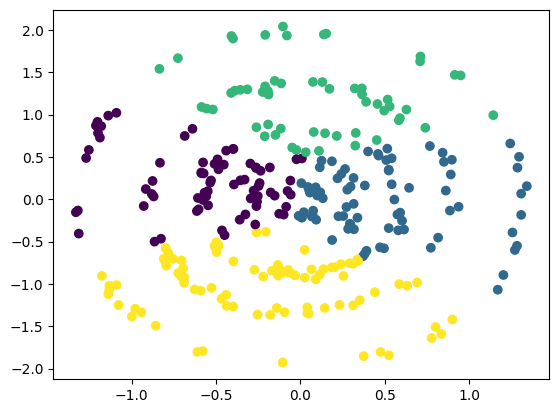

In [14]:
fig, ax = plt.subplots()
ax.scatter(pts_n['x'], pts_n['y'], c=pts_n['cluster_Km4'])

In [15]:
fig.savefig('kmeans.png')

## DBScan

In [16]:
from sklearn.cluster import DBSCAN

In [17]:
db = DBSCAN(min_samples=3).fit(X)
labels = db.labels_

pts_n.loc[:, 'cluster_DBscan'] = labels

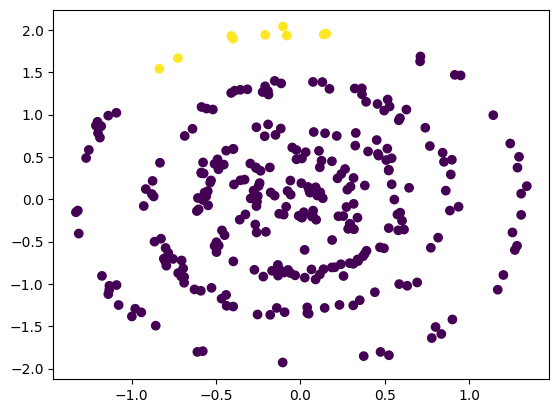

In [18]:
fig, ax = plt.subplots()
ax.scatter(pts_n['x'], pts_n['y'], c=pts_n['cluster_DBscan'])

In [19]:
fig.savefig('dbscan.png')

## Agglomerative HC

In [20]:
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering

In [21]:
def plot_dendogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
                
        counts[i] = current_count
        
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)
    
    dendrogram(linkage_matrix, **kwargs)

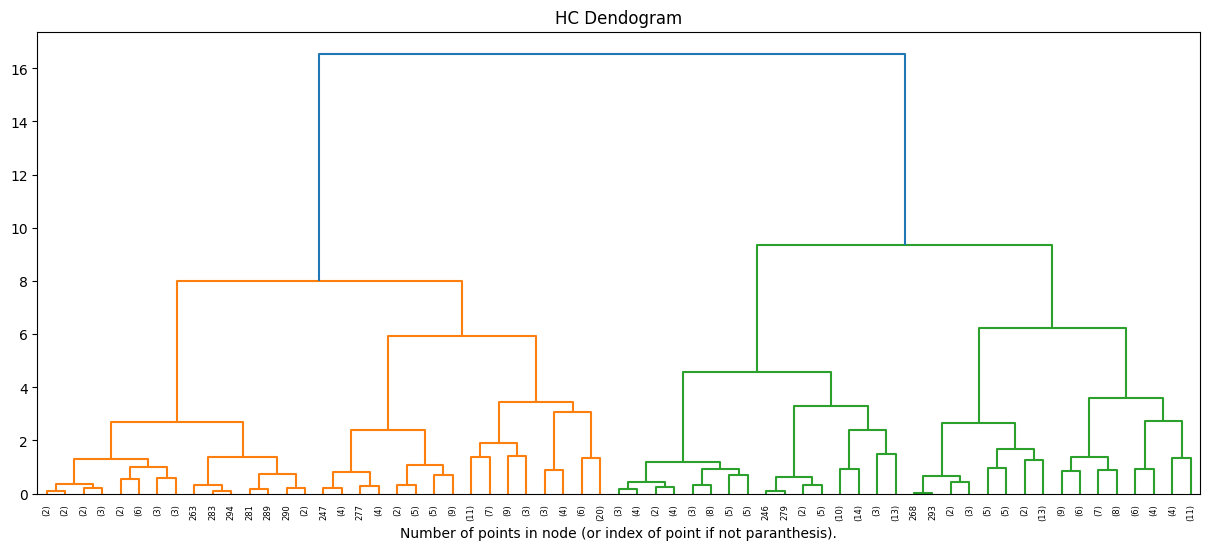

In [22]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X)
plt.figure(figsize=(15, 6))
plt.title('HC Dendogram')
plot_dendogram(model, truncate_mode='level', p=5)
plt.xlabel('Number of points in node (or index of point if not paranthesis).')
# plt.axhline()
plt.show()

In [23]:
model = AgglomerativeClustering(
    n_clusters=4, compute_distances=True
)
model.fit(X)
cluster_labels = model.labels_
pts_n.loc[:, 'cluster_AGG4'] = cluster_labels

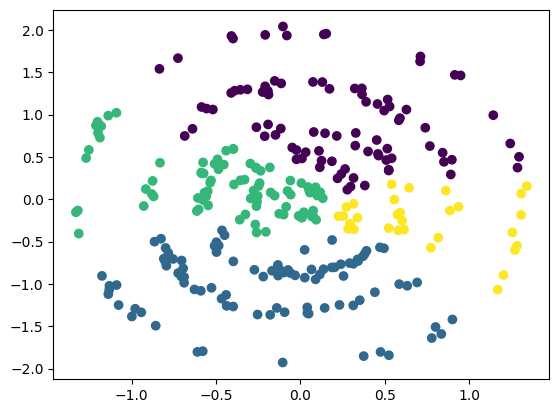

In [24]:
fig, ax = plt.subplots()
ax.scatter(pts_n['x'], pts_n['y'], c=pts_n['cluster_AGG4'])

In [25]:
fig.savefig('agg.png')

## Spectral clustering

In [26]:
from sklearn.cluster import SpectralClustering

In [27]:
model = SpectralClustering(
    n_clusters=4, n_neighbors=15, gamma=25, random_state=seed
)
cluster_labels = model.fit_predict(X)
pts_n.loc[:, 'cluster_SC4'] = cluster_labels

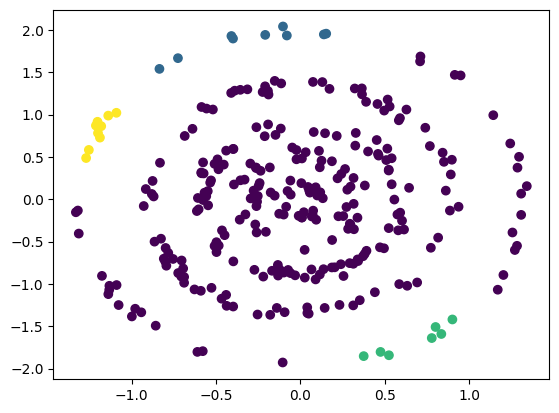

In [28]:
fig, ax = plt.subplots()
ax.scatter(pts_n['x'], pts_n['y'], c=pts_n['cluster_SC4'])

In [29]:
fig.savefig('spectral.png')

---

# Ellipsoids: manual rule building

In [30]:
a = (pts['x'].max() - pts['x'].min())/2
b = (pts['y'].max() - pts['y'].min())/2

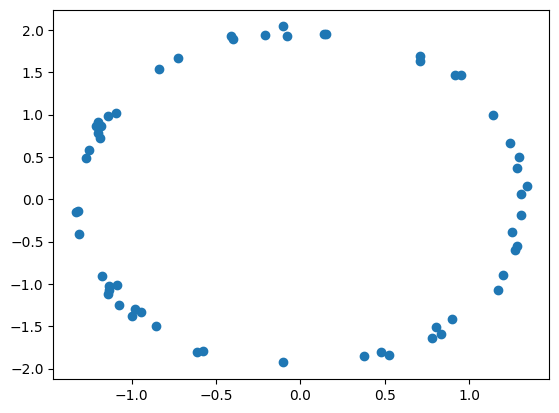

In [31]:
part = pts[((pts['x']/a)**2 + (pts['y']/b)**2) > 0.514]
part_1 = pts[(((pts['x']/a)**2 + (pts['y']/b)**2) > 0.246) & (((pts['x']/a)**2 + (pts['y']/b)**2) <= 0.514)]
part_2 = pts[(((pts['x']/a)**2 + (pts['y']/b)**2) > 0.097) & (((pts['x']/a)**2 + (pts['y']/b)**2) <= 0.246)]
part_3 = pts[((pts['x']/a)**2 + (pts['y']/b)**2) <= 0.097]

plt.scatter(part['x'], part['y'])

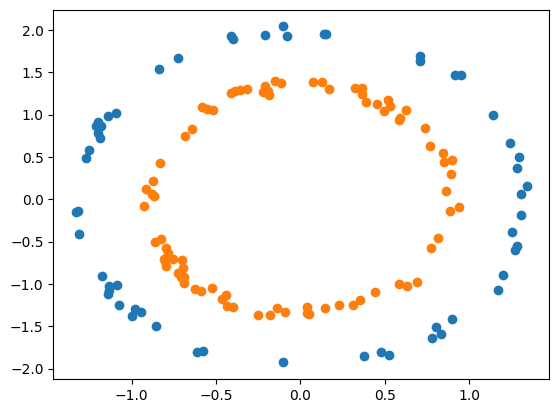

In [32]:
plt.scatter(part['x'], part['y'])
plt.scatter(part_1['x'], part_1['y'])

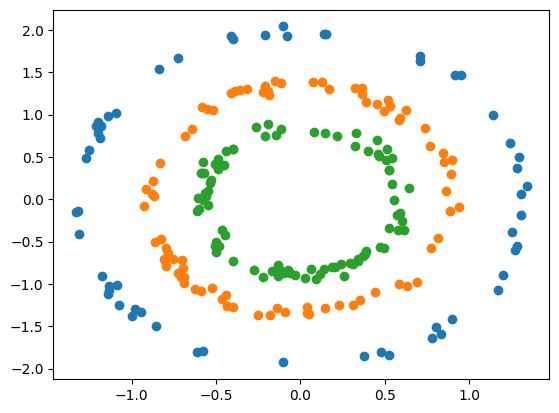

In [33]:
plt.scatter(part['x'], part['y'])
plt.scatter(part_1['x'], part_1['y'])
plt.scatter(part_2['x'], part_2['y'])

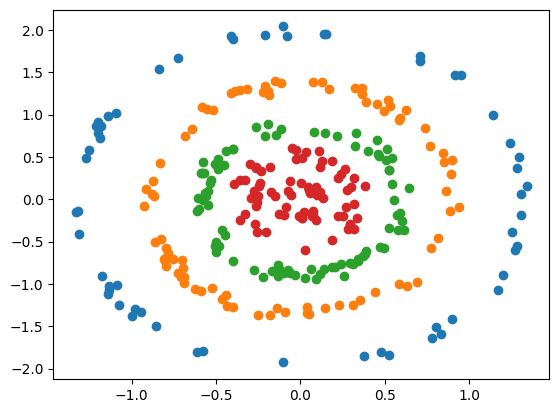

In [34]:
plt.scatter(part['x'], part['y'])
plt.scatter(part_1['x'], part_1['y'])
plt.scatter(part_2['x'], part_2['y'])
plt.scatter(part_3['x'], part_3['y'])

# Feature engineering

In [35]:
pts = pts.assign(r2 = lambda x: np.power(x['x'], 2)/np.power(a, 2) + np.power(x['y'], 2)/np.power(b, 2))

## Visualizing transformed feature

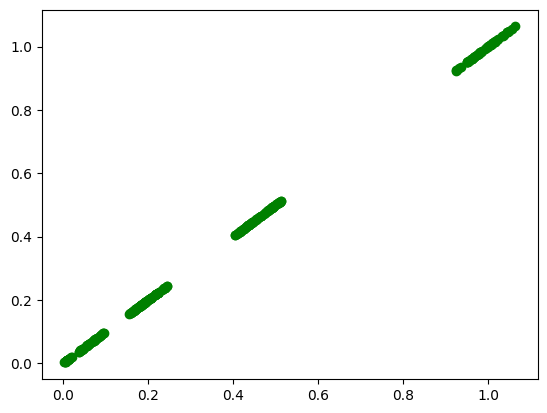

In [36]:
plt.scatter(pts['r2'], pts['r2'], color='g')

**The points look easily seperable**

## Using Kmeans to find the clusters

In [37]:
kmeans = KMeans(n_clusters=4) 
kmeans.fit(pts[['r2']])

KMeans(n_clusters=4)

In [38]:
cl = kmeans.predict(pts[['r2']])

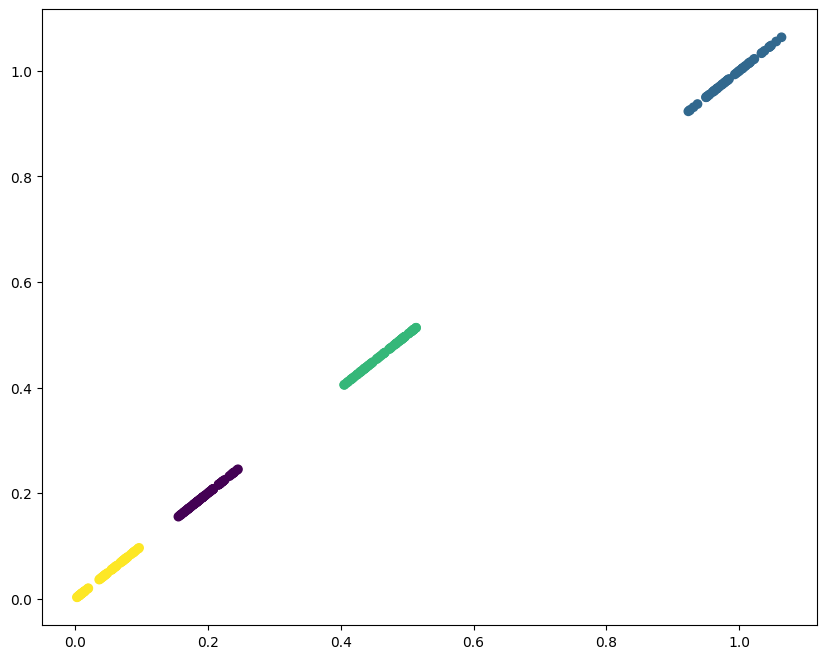

In [39]:
plt.figure(figsize=(10, 8))
plt.scatter(pts['r2'], pts['r2'], c=cl)

## Assigning clusters to original 'x' and 'y'

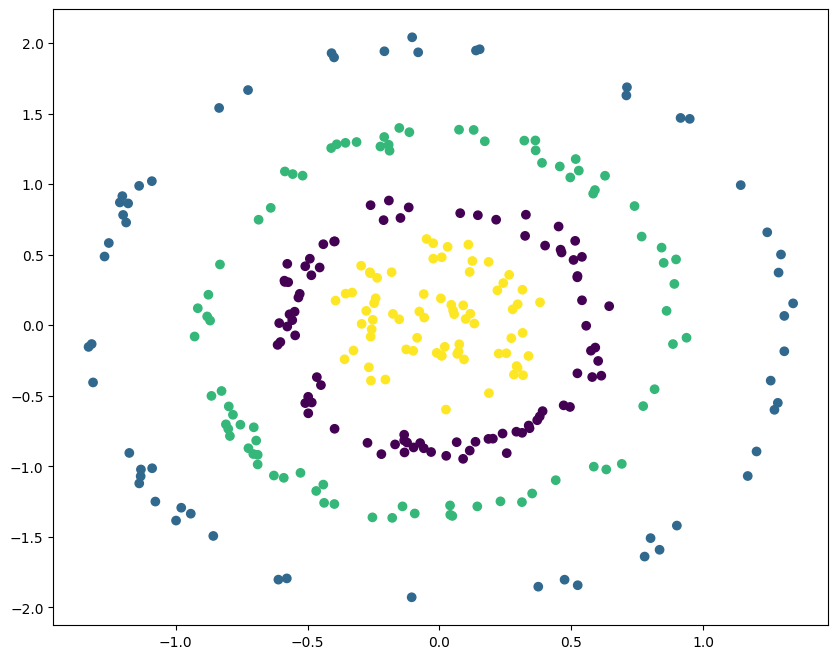

In [40]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 8)
ax.scatter(pts['x'], pts['y'], c=cl)

In [ ]:
fig.savefig('final.png')

---